# Batch Inference FirstPass + Tracking per Cyclone

Notebook per:
- lanciare `scripts/predict_firstpass_and_track_from_folder.py` su tutte le cartelle `fromgcloud/<id_ciclone>`;
- usare la soglia per-ciclone dalla **ultima cella** di `moduli/firstpass/notebooks/per_cyclone_threshold_analysis.ipynb`;
- analizzare la distribuzione degli errori di tracking (km);
- visualizzare la traccia GT vs predetta su mappa Mediterraneo.

La cella di esecuzione subprocess usa solo variabili definite nel notebook.


In [1]:
from __future__ import annotations

import ast
import json
import shlex
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


In [2]:
# Risoluzione root repo in modo robusto

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'scripts' / 'predict_firstpass_and_track_from_folder.py').exists():
            return p
    raise FileNotFoundError('Repository root non trovato a partire da cwd.')

REPO_ROOT = find_repo_root(Path.cwd())
SCRIPT_PATH = REPO_ROOT / 'scripts' / 'predict_firstpass_and_track_from_folder.py'
THRESH_NOTEBOOK = REPO_ROOT / 'moduli' / 'firstpass' / 'notebooks' / 'per_cyclone_threshold_analysis.ipynb'

print('REPO_ROOT:', REPO_ROOT)
print('SCRIPT_PATH:', SCRIPT_PATH)
print('THRESH_NOTEBOOK:', THRESH_NOTEBOOK)


REPO_ROOT: /media/isacDisk1/Demetra
SCRIPT_PATH: /media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py
THRESH_NOTEBOOK: /media/isacDisk1/Demetra/moduli/firstpass/notebooks/per_cyclone_threshold_analysis.ipynb


In [3]:
# Caricamento soglie dalla ULTIMA cella code non vuota del notebook per-cyclone

def normalize_cyclone_id(v) -> str:
    if pd.isna(v):
        return ''
    s = str(v).strip()
    if not s:
        return ''
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return s


def extract_thresholds_from_last_cell(nb_path: Path) -> dict[str, float]:
    nb = json.loads(nb_path.read_text())
    code_cells = [
        ''.join(c.get('source', []))
        for c in nb.get('cells', [])
        if c.get('cell_type') == 'code' and ''.join(c.get('source', [])).strip()
    ]
    if not code_cells:
        raise RuntimeError(f'Nessuna cella code non vuota in {nb_path}')

    last_src = code_cells[-1]
    tree = ast.parse(last_src)

    dict_obj = None
    for node in tree.body:
        if isinstance(node, ast.Assign) and isinstance(node.value, ast.Dict):
            try:
                candidate = ast.literal_eval(node.value)
            except Exception:
                continue
            if isinstance(candidate, dict) and candidate:
                dict_obj = candidate

    if not isinstance(dict_obj, dict) or not dict_obj:
        raise RuntimeError(
            'Ultima cella code non contiene un dizionario soglie assegnato. '
            'Controlla per_cyclone_threshold_analysis.ipynb'
        )

    out: dict[str, float] = {}
    for k, v in dict_obj.items():
        kid = normalize_cyclone_id(k)
        if not kid:
            continue
        try:
            out[kid] = float(v)
        except Exception:
            continue

    if not out:
        raise RuntimeError('Dizionario soglie estratto ma vuoto/non valido.')
    return out


THRESHOLDS_BY_ID = extract_thresholds_from_last_cell(THRESH_NOTEBOOK)
print('Soglie caricate:', len(THRESHOLDS_BY_ID))
print('Esempio:', list(THRESHOLDS_BY_ID.items()))


Soglie caricate: 18
Esempio: [('7001702', 0.3), ('7001283', 0.335), ('7001328', 0.515), ('7001358', 0.255), ('7001421', 0.465), ('7001461', 0.19), ('7001466', 0.335), ('7001500', 0.435), ('7001521', 0.395), ('7001542', 0.56), ('7001575', 0.635), ('7001674', 0.43), ('7001715', 0.06), ('7001716', 0.065), ('39299', 0.09), ('82258', 0.125), ('46218', 0.245), ('83565', 0.21)]


In [18]:
# Configurazione batch run (modifica qui)

PYTHON_BIN = sys.executable
FROMGCLOUD_DIR = Path('/media/isacDisk1/fromgcloud')
#OUTPUT_ROOT = Path('/media/isacDisk1/airmassRGB')
OUTPUT_ROOT = Path('/media/isacDisk2/demetra_output/')

FIRSTPASS_MODEL_PATH = REPO_ROOT / 'trained_models' / 'firstpass_model.ckpt'
TRACKING_MODEL_PATH = REPO_ROOT / 'trained_models' / 'checkpoint-tracking-best_1.pth'
MANOS_FILE = REPO_ROOT / 'moduli' / 'videomae' / 'medicane_data_input' / 'medicanes_new_windows.csv'

FIRSTPASS_BATCH_SIZE = 64
FIRSTPASS_NUM_WORKERS = 16


# Se vuoi filtrare un sottoinsieme: ['7001421', '83565']
SELECT_ONLY_IDS = None

# Fallback se un id non ha soglia specifica nel dizionario
DEFAULT_THRESHOLD = 0.50

# Sicurezza: metti True per eseguire davvero
RUN_ENABLED = True

FFMPEG_PATH = '/mnt/share/Demetra_files/VideoMAEv2/ffmpeg-7.0.2-amd64-static/'

print('OUTPUT_ROOT:', OUTPUT_ROOT)


OUTPUT_ROOT: /media/isacDisk2/demetra_output


In [5]:
# Scansione cartelle input e piano esecuzione

if not FROMGCLOUD_DIR.exists():
    raise FileNotFoundError(f'Input root non trovata: {FROMGCLOUD_DIR}')

all_dirs = sorted([p for p in FROMGCLOUD_DIR.iterdir() if p.is_dir()])
plan_rows = []
for d in all_dirs:
    cid = normalize_cyclone_id(d.name)
    if not cid:
        continue
    if SELECT_ONLY_IDS is not None and cid not in {normalize_cyclone_id(x) for x in SELECT_ONLY_IDS}:
        continue
    thr = float(THRESHOLDS_BY_ID.get(cid, DEFAULT_THRESHOLD))
    out_dir = OUTPUT_ROOT / cid
    plan_rows.append({
        'cyclone_id': cid,
        'input_dir': str(d),
        'output_dir': str(out_dir),
        'firstpass_threshold': thr,
        'threshold_source': 'per_cyclone' if cid in THRESHOLDS_BY_ID else 'default',
    })

plan_df = pd.DataFrame(plan_rows).sort_values('cyclone_id').reset_index(drop=True)
print(f'Cyclone folders in piano: {len(plan_df)}')
plan_df.head(20)


Cyclone folders in piano: 20


,cyclone_id,input_dir,output_dir,firstpass_threshold,threshold_source
0,2020,/media/isacDisk1/fromgcloud/2020,/media/isacDisk2/demetra_output/2020,0.500,default
1,2023,/media/isacDisk1/fromgcloud/2023,/media/isacDisk2/demetra_output/2023,0.500,default
2,39299,/media/isacDisk1/fromgcloud/39299,/media/isacDisk2/demetra_output/39299,0.090,per_cyclone
3,46218,/media/isacDisk1/fromgcloud/46218,/media/isacDisk2/demetra_output/46218,0.245,per_cyclone
4,7001283,/media/isacDisk1/fromgcloud/7001283,/media/isacDisk2/demetra_output/7001283,0.335,per_cyclone
5,7001328,/media/isacDisk1/fromgcloud/7001328,/media/isacDisk2/demetra_output/7001328,0.515,per_cyclone
6,7001358,/media/isacDisk1/fromgcloud/7001358,/media/isacDisk2/demetra_output/7001358,0.255,per_cyclone
7,7001421,/media/isacDisk1/fromgcloud/7001421,/media/isacDisk2/demetra_output/7001421,0.465,per_cyclone
8,7001461,/media/isacDisk1/fromgcloud/7001461,/media/isacDisk2/demetra_output/7001461,0.190,per_cyclone
9,7001466,/media/isacDisk1/fromgcloud/7001466,/media/isacDisk2/demetra_output/7001466,0.335,per_cyclone


In [15]:
plan_df.loc[plan_df.cyclone_id == '2020', 'firstpass_threshold'] = round(np.mean(list(THRESHOLDS_BY_ID.values())), 3)

In [6]:
plan_df = plan_df[2:]
plan_df

,cyclone_id,input_dir,output_dir,firstpass_threshold,threshold_source
2,39299,/media/isacDisk1/fromgcloud/39299,/media/isacDisk2/demetra_output/39299,0.090,per_cyclone
3,46218,/media/isacDisk1/fromgcloud/46218,/media/isacDisk2/demetra_output/46218,0.245,per_cyclone
4,7001283,/media/isacDisk1/fromgcloud/7001283,/media/isacDisk2/demetra_output/7001283,0.335,per_cyclone
5,7001328,/media/isacDisk1/fromgcloud/7001328,/media/isacDisk2/demetra_output/7001328,0.515,per_cyclone
6,7001358,/media/isacDisk1/fromgcloud/7001358,/media/isacDisk2/demetra_output/7001358,0.255,per_cyclone
7,7001421,/media/isacDisk1/fromgcloud/7001421,/media/isacDisk2/demetra_output/7001421,0.465,per_cyclone
8,7001461,/media/isacDisk1/fromgcloud/7001461,/media/isacDisk2/demetra_output/7001461,0.190,per_cyclone
9,7001466,/media/isacDisk1/fromgcloud/7001466,/media/isacDisk2/demetra_output/7001466,0.335,per_cyclone
10,7001500,/media/isacDisk1/fromgcloud/7001500,/media/isacDisk2/demetra_output/7001500,0.435,per_cyclone
11,7001521,/media/isacDisk1/fromgcloud/7001521,/media/isacDisk2/demetra_output/7001521,0.395,per_cyclone


In [19]:
# Esecuzione batch via subprocess

def build_cmd(row: pd.Series) -> list[str]:
    cmd = [
        str(PYTHON_BIN),
        str(SCRIPT_PATH),
        '--input_dir', str(row['input_dir']),
        '--output_dir', str(row['output_dir']),
        '--firstpass_model_path', str(FIRSTPASS_MODEL_PATH),
        '--tracking_model_path', str(TRACKING_MODEL_PATH),
        '--firstpass_threshold', f"{float(row['firstpass_threshold']):.3f}",
        '--manos_file', str(MANOS_FILE),
        '--firstpass_batch_size', str(int(FIRSTPASS_BATCH_SIZE)),
        '--firstpass_num_workers', str(int(FIRSTPASS_NUM_WORKERS)),
        '--standard_tiling',
        '--make_video',
        '--ffmpeg_path', str(FFMPEG_PATH),
    ]
    return cmd

run_rows = []
if not RUN_ENABLED:
    print('RUN_ENABLED=False: nessun subprocess lanciato. Metti RUN_ENABLED=True e rilancia questa cella.')
else:
    for _, row in plan_df.iterrows():
        cmd = build_cmd(row)
        print('\n' + '=' * 100)
        print(f"Cyclone {row['cyclone_id']} | threshold={row['firstpass_threshold']:.3f} ({row['threshold_source']})")
        print(shlex.join(cmd))

        t0 = time.time()
        proc = subprocess.run(cmd, cwd=str(REPO_ROOT), text=True)
        dt = time.time() - t0

        run_rows.append({
            'cyclone_id': row['cyclone_id'],
            'return_code': int(proc.returncode),
            'elapsed_sec': round(dt, 2),
            'output_dir': row['output_dir'],
            'threshold': float(row['firstpass_threshold']),
        })

run_df = pd.DataFrame(run_rows)
if not run_df.empty:
    display(run_df)
    print('Fail count:', int((run_df['return_code'] != 0).sum()))
else:
    print('Nessun run eseguito.')
    



Cyclone 39299 | threshold=0.090 (per_cyclone)
/home/isac/miniconda3/envs/videomae/bin/python /media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py --input_dir /media/isacDisk1/fromgcloud/39299 --output_dir /media/isacDisk2/demetra_output/39299 --firstpass_model_path /media/isacDisk1/Demetra/trained_models/firstpass_model.ckpt --tracking_model_path /media/isacDisk1/Demetra/trained_models/checkpoint-tracking-best_1.pth --firstpass_threshold 0.090 --manos_file /media/isacDisk1/Demetra/moduli/videomae/medicane_data_input/medicanes_new_windows.csv --firstpass_batch_size 64 --firstpass_num_workers 16 --standard_tiling --make_video --ffmpeg_path /mnt/share/Demetra_files/VideoMAEv2/ffmpeg-7.0.2-amd64-static/
Impossibile caricare la libreria torch dynamo
[INFO] CSV finale gia presente: /media/isacDisk2/demetra_output/39299/tracking_inference_predictions.csv. Salto inferenze.
[INFO] Frames raccolti: 1212 (2021-10-27 09:20:00 -> 2021-10-31 14:15:00)
[INFO] GT points caricat

ffmpeg version 7.0.2-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libvorbis --enable-libopus --enable-libtheora --enable-libvidstab --enable-libvo-amrwbenc --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libdav1d --enable-libxvid --enable-libzvbi --enable-libzimg
  libavutil      59.  8.100 / 59.  8.100
  libavcodec     61.  3.100 / 61.  3.100
  libavformat   

[INFO] Video ROI first-pass generato: /media/isacDisk2/demetra_output/39299/mediterraneo_predizioni.mp4

Cyclone 46218 | threshold=0.245 (per_cyclone)
/home/isac/miniconda3/envs/videomae/bin/python /media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py --input_dir /media/isacDisk1/fromgcloud/46218 --output_dir /media/isacDisk2/demetra_output/46218 --firstpass_model_path /media/isacDisk1/Demetra/trained_models/firstpass_model.ckpt --tracking_model_path /media/isacDisk1/Demetra/trained_models/checkpoint-tracking-best_1.pth --firstpass_threshold 0.245 --manos_file /media/isacDisk1/Demetra/moduli/videomae/medicane_data_input/medicanes_new_windows.csv --firstpass_batch_size 64 --firstpass_num_workers 16 --standard_tiling --make_video --ffmpeg_path /mnt/share/Demetra_files/VideoMAEv2/ffmpeg-7.0.2-amd64-static/
Impossibile caricare la libreria torch dynamo
[INFO] CSV finale gia presente: /media/isacDisk2/demetra_output/46218/tracking_inference_predictions.csv. Salto infer

ffmpeg version 7.0.2-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libvorbis --enable-libopus --enable-libtheora --enable-libvidstab --enable-libvo-amrwbenc --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libdav1d --enable-libxvid --enable-libzvbi --enable-libzimg
  libavutil      59.  8.100 / 59.  8.100
  libavcodec     61.  3.100 / 61.  3.100
  libavformat   

[INFO] Video ROI first-pass generato: /media/isacDisk2/demetra_output/46218/mediterraneo_predizioni.mp4

Cyclone 7001283 | threshold=0.335 (per_cyclone)
/home/isac/miniconda3/envs/videomae/bin/python /media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py --input_dir /media/isacDisk1/fromgcloud/7001283 --output_dir /media/isacDisk2/demetra_output/7001283 --firstpass_model_path /media/isacDisk1/Demetra/trained_models/firstpass_model.ckpt --tracking_model_path /media/isacDisk1/Demetra/trained_models/checkpoint-tracking-best_1.pth --firstpass_threshold 0.335 --manos_file /media/isacDisk1/Demetra/moduli/videomae/medicane_data_input/medicanes_new_windows.csv --firstpass_batch_size 64 --firstpass_num_workers 16 --standard_tiling --make_video --ffmpeg_path /mnt/share/Demetra_files/VideoMAEv2/ffmpeg-7.0.2-amd64-static/
Impossibile caricare la libreria torch dynamo
[INFO] CSV finale gia presente: /media/isacDisk2/demetra_output/7001283/tracking_inference_predictions.csv. Sal

...

[INFO] Video ROI first-pass generato: /media/isacDisk2/demetra_output/82258/mediterraneo_predizioni.mp4

Cyclone 83565 | threshold=0.210 (per_cyclone)
/home/isac/miniconda3/envs/videomae/bin/python /media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py --input_dir /media/isacDisk1/fromgcloud/83565 --output_dir /media/isacDisk2/demetra_output/83565 --firstpass_model_path /media/isacDisk1/Demetra/trained_models/firstpass_model.ckpt --tracking_model_path /media/isacDisk1/Demetra/trained_models/checkpoint-tracking-best_1.pth --firstpass_threshold 0.210 --manos_file /media/isacDisk1/Demetra/moduli/videomae/medicane_data_input/medicanes_new_windows.csv --firstpass_batch_size 64 --firstpass_num_workers 16 --standard_tiling --make_video --ffmpeg_path /mnt/share/Demetra_files/VideoMAEv2/ffmpeg-7.0.2-amd64-static/
Impossibile caricare la libreria torch dynamo
[INFO] CSV finale gia presente: /media/isacDisk2/demetra_output/83565/tracking_inference_predictions.csv. Salto infer

ffmpeg version 7.0.2-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libvorbis --enable-libopus --enable-libtheora --enable-libvidstab --enable-libvo-amrwbenc --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libdav1d --enable-libxvid --enable-libzvbi --enable-libzimg
  libavutil      59.  8.100 / 59.  8.100
  libavcodec     61.  3.100 / 61.  3.100
  libavformat   

[INFO] Video ROI first-pass generato: /media/isacDisk2/demetra_output/83565/mediterraneo_predizioni.mp4


,cyclone_id,return_code,elapsed_sec,output_dir,threshold
0,39299,0,117.83,/media/isacDisk2/demetra_output/39299,0.090
1,46218,0,260.24,/media/isacDisk2/demetra_output/46218,0.245
2,7001283,0,64.47,/media/isacDisk2/demetra_output/7001283,0.335
3,7001328,0,129.84,/media/isacDisk2/demetra_output/7001328,0.515
4,7001358,0,101.97,/media/isacDisk2/demetra_output/7001358,0.255
5,7001421,0,82.47,/media/isacDisk2/demetra_output/7001421,0.465
6,7001461,0,91.78,/media/isacDisk2/demetra_output/7001461,0.190
7,7001466,0,174.32,/media/isacDisk2/demetra_output/7001466,0.335
8,7001500,0,62.20,/media/isacDisk2/demetra_output/7001500,0.435
9,7001521,0,78.00,/media/isacDisk2/demetra_output/7001521,0.395


Fail count: 0


In [8]:
# Raccolta CSV tracking tile-level dai run (utile per metriche err_px / err_km)

if 'run_df' in globals() and not run_df.empty:
    source_df = run_df.copy()
else:
    source_df = plan_df.copy()

rows = []
for _, r in source_df.iterrows():
    cid = normalize_cyclone_id(r['cyclone_id'])
    out_dir = Path(r['output_dir'])
    csv_path = out_dir / '_tmp_tracking_inference_predictions_tiles.csv'
    if not csv_path.exists():
        continue
    try:
        df = pd.read_csv(csv_path)
    except Exception as exc:
        print(f'[WARN] Impossibile leggere {csv_path}: {exc}')
        continue
    df['cyclone_id'] = cid
    df['output_dir'] = str(out_dir)
    rows.append(df)

if rows:
    all_tile_preds = pd.concat(rows, ignore_index=True)
else:
    all_tile_preds = pd.DataFrame()

print('Rows tile predictions:', len(all_tile_preds))
if not all_tile_preds.empty:
    if 'has_target' in all_tile_preds.columns:
        print('has_target counts:', all_tile_preds['has_target'].value_counts(dropna=False).to_dict())
    display(all_tile_preds.head(10))


Rows tile predictions: 4380
has_target counts: {0: 4171, 1: 209}


,path,has_target,pred_x,pred_y,target_x,target_y,err_px,err_km,tile_offset_x,tile_offset_y,pred_x_global,pred_y_global,pred_lat,pred_lon,cyclone_id,output_dir,target_x_global,target_y_global,target_lat,target_lon
0,27-10-2021_1035_426_196,0,91,46,NaN,NaN,NaN,NaN,426.0,196.0,517,242,36.08,9.83,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
1,27-10-2021_1050_426_196,0,100,57,NaN,NaN,NaN,NaN,426.0,196.0,526,253,35.66,10.14,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
2,27-10-2021_1105_426_196,0,104,49,NaN,NaN,NaN,NaN,426.0,196.0,530,245,35.96,10.28,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
3,27-10-2021_1120_426_196,0,92,35,NaN,NaN,NaN,NaN,426.0,196.0,518,231,36.49,9.87,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
4,27-10-2021_1135_426_196,0,96,54,NaN,NaN,NaN,NaN,426.0,196.0,522,250,35.77,10.00,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
5,27-10-2021_1150_426_196,0,86,45,NaN,NaN,NaN,NaN,426.0,196.0,512,241,36.11,9.66,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
6,27-10-2021_1205_426_196,0,79,34,NaN,NaN,NaN,NaN,426.0,196.0,505,230,36.53,9.42,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
7,27-10-2021_1220_426_196,0,86,48,NaN,NaN,NaN,NaN,426.0,196.0,512,244,36.00,9.66,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
8,27-10-2021_1235_426_196,0,91,58,NaN,NaN,NaN,NaN,426.0,196.0,517,254,35.62,9.83,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
9,27-10-2021_1250_426_196,0,91,55,NaN,NaN,NaN,NaN,426.0,196.0,517,251,35.74,9.83,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN


Rows with GT (has_target=1, hourly-only, err_km>0): 204


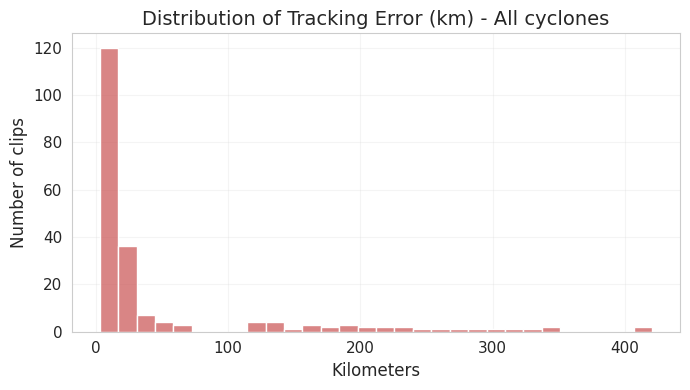

Saved: /media/isacDisk1/Demetra/notebooks/batch_outputs/tracking_error_distribution_all_cyclones.png
Median err_km (all): 13.963925350474945
Mean err_km (all): 49.16357087451259
Istogrammi per-ciclone salvati: 5


,cyclone_id,n,median_err_km,mean_err_km,hist_path
0,7001421,24,13.223095,16.214087,/media/isacDisk1/Demetra/notebooks/batch_outpu...
1,7001461,36,18.382430,86.058188,/media/isacDisk1/Demetra/notebooks/batch_outpu...
2,7001466,69,13.611358,67.560414,/media/isacDisk1/Demetra/notebooks/batch_outpu...
3,7001575,45,10.011093,17.546942,/media/isacDisk1/Demetra/notebooks/batch_outpu...
4,7001674,30,18.640987,36.361822,/media/isacDisk1/Demetra/notebooks/batch_outpu...


In [9]:
# ### Distribuzione degli errori (solo GT oraria, no interpolazione temporale)
# Salva un istogramma globale e uno per ciascun cyclone_id disponibile.

BATCH_OUT_DIR = REPO_ROOT / 'notebooks' / 'batch_outputs'
HIST_OUT_DIR = BATCH_OUT_DIR / 'hist_per_cyclone'
BATCH_OUT_DIR.mkdir(parents=True, exist_ok=True)
HIST_OUT_DIR.mkdir(parents=True, exist_ok=True)

if all_tile_preds.empty or 'err_km' not in all_tile_preds.columns or not all_tile_preds['err_km'].notna().any():
    print('err_km column not available')
else:
    err_df = all_tile_preds.copy()

    if 'has_target' in err_df.columns:
        err_df = err_df[pd.to_numeric(err_df['has_target'], errors='coerce') == 1]

    if 'path' in err_df.columns:
        path_base = err_df['path'].astype(str).str.replace(r'.*[\/]', '', regex=True)
        dt_str = path_base.str.extract(r'^(\d{2}-\d{2}-\d{4}_\d{4})', expand=False)
        tile_dt = pd.to_datetime(dt_str, format='%d-%m-%Y_%H%M', errors='coerce')
        err_df = err_df[tile_dt.notna() & (tile_dt.dt.minute == 0)].copy()

    err_df['err_km'] = pd.to_numeric(err_df['err_km'], errors='coerce')
    err_df = err_df[err_df['err_km'].notna() & (err_df['err_km'] > 0)].copy()

    print('Rows with GT (has_target=1, hourly-only, err_km>0):', len(err_df))

    if err_df.empty:
        print('Nessun errore valido da plottare.')
    else:
        # Istogramma globale
        fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
        sns.histplot(err_df['err_km'], bins=30, ax=ax, color='indianred')
        ax.set_title('Distribution of Tracking Error (km) - All cyclones', fontsize=14)
        ax.set_xlabel('Kilometers', fontsize=12)
        ax.set_ylabel('Number of clips', fontsize=12)
        ax.tick_params(axis='both', labelsize=11)
        ax.grid(alpha=0.2)
        global_png = BATCH_OUT_DIR / 'tracking_error_distribution_all_cyclones.png'
        fig.savefig(global_png, dpi=150)
        plt.show()
        plt.close(fig)
        print('Saved:', global_png)
        print('Median err_km (all):', float(np.median(err_df['err_km'])))
        print('Mean err_km (all):', float(np.mean(err_df['err_km'])))

        # Istogrammi per cyclone_id
        if 'cyclone_id' in err_df.columns:
            hist_rows = []
            for cid, g in err_df.groupby('cyclone_id'):
                cid = normalize_cyclone_id(cid)
                if not cid:
                    continue
                vals = pd.to_numeric(g['err_km'], errors='coerce').dropna()
                vals = vals[vals > 0]
                if vals.empty:
                    continue

                fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
                sns.histplot(vals, bins=30, ax=ax, color='indianred')
                ax.set_title(f'Distribution of Tracking Error (km) - Cyclone {cid}', fontsize=13)
                ax.set_xlabel('Kilometers', fontsize=11)
                ax.set_ylabel('Number of clips', fontsize=11)
                ax.grid(alpha=0.2)

                out_png = HIST_OUT_DIR / f'tracking_error_distribution_{cid}.png'
                fig.savefig(out_png, dpi=150)
                plt.close(fig)

                hist_rows.append({
                    'cyclone_id': cid,
                    'n': int(len(vals)),
                    'median_err_km': float(np.median(vals)),
                    'mean_err_km': float(np.mean(vals)),
                    'hist_path': str(out_png),
                })

            hist_summary_df = pd.DataFrame(hist_rows).sort_values('cyclone_id').reset_index(drop=True)
            print('Istogrammi per-ciclone salvati:', len(hist_summary_df))
            if not hist_summary_df.empty:
                display(hist_summary_df.head(20))



In [28]:
# Configurazione mappe Mediterraneo per TUTTI i cicloni del piano
# + helper unificati per plotting mappe/tracce (riusati anche nella sezione CL7)

if 'create_basemap_obj' not in globals():
    VIDEOMAE_DIR = REPO_ROOT / 'moduli' / 'videomae'
    if str(VIDEOMAE_DIR) not in sys.path:
        sys.path.insert(0, str(VIDEOMAE_DIR))
    from medicane_utils.geo_const import latcorners, loncorners, create_basemap_obj


def _nearest_to_hour(df: pd.DataFrame, time_col: str) -> pd.DataFrame:
    work = df.copy()
    work[time_col] = pd.to_datetime(work[time_col], errors='coerce')
    work = work[work[time_col].notna()].copy()
    if work.empty:
        return work
    work['hour_key'] = work[time_col].dt.round('h')
    work['dist_hour_sec'] = (work[time_col] - work['hour_key']).abs().dt.total_seconds()
    work = (
        work.sort_values(['hour_key', 'dist_hour_sec', time_col])
        .drop_duplicates(subset=['hour_key'], keep='first')
        .sort_values(time_col)
        .drop(columns=['hour_key', 'dist_hour_sec'])
        .reset_index(drop=True)
    )
    return work


def _build_id_aliases(cyclone_id: str) -> set:
    cid = normalize_cyclone_id(cyclone_id)
    aliases = {cid} if cid else set()
    if cid and cid.isdigit():
        if cid.startswith('700') and len(cid) > 3:
            aliases.add(cid[3:])
        else:
            aliases.add('700' + cid)
    return {a for a in aliases if a}


def _select_rows_by_aliases(df: pd.DataFrame, aliases: set, id_cols: list) -> pd.DataFrame:
    if df is None or df.empty or not aliases:
        return df.iloc[0:0].copy() if isinstance(df, pd.DataFrame) else pd.DataFrame([])
    mask = pd.Series(False, index=df.index)
    for c in id_cols:
        if c in df.columns:
            mask = mask | df[c].astype(str).isin(aliases)
    return df[mask].copy()


def _infer_gt_interval(gt_df: pd.DataFrame) -> tuple:
    if gt_df is None or gt_df.empty:
        return (pd.NaT, pd.NaT)

    t = pd.to_datetime(gt_df.get('time'), errors='coerce')
    t = t[t.notna()]
    start = t.min() if not t.empty else pd.NaT
    end = t.max() if not t.empty else pd.NaT

    if 'start_time' in gt_df.columns:
        st = pd.to_datetime(gt_df.get('start_time'), errors='coerce')
        st = st[st.notna()]
        if not st.empty:
            start = st.min()

    if 'end_time' in gt_df.columns:
        en = pd.to_datetime(gt_df.get('end_time'), errors='coerce')
        en = en[en.notna()]
        if not en.empty:
            end = en.max()

    return (start, end)


def _build_track_title(cyclone_id: str, gt_df: pd.DataFrame = None) -> str:
    cid = normalize_cyclone_id(cyclone_id)
    if cid.startswith('700') and len(cid) > 3:
        return f'Track id {cid[3:]}'

    if gt_df is not None and not gt_df.empty and 'name' in gt_df.columns:
        names = gt_df['name'].dropna().astype(str).str.strip()
        names = names[names != '']
        if not names.empty:
            return names.iloc[0]

    return f'Track id {cid}' if cid else 'Track id'


def _plot_med_tracks_map(
    out_png: Path,
    title: str,
    gt_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    mercad_df: pd.DataFrame = None,
    gt_label: str = 'Ground Truth',
    pred_label: str = 'Prediction',
    mercad_label: str = 'MERCAD',
    pred_connect_window: tuple = None,
    dpi: int = 150,
) -> None:
    # geos projection over Mediterranean is very wide; use panoramic figure to avoid large top/bottom blank areas
    fig = plt.figure(figsize=(12, 4.2), dpi=dpi)
    ax = fig.add_axes([0.10, 0.08, 0.84, 0.88])
    m = create_basemap_obj(ax=ax)
    m.drawcoastlines(linewidth=0.8, color='black', zorder=2)

    lat_min, lat_max = latcorners
    lon_min, lon_max = loncorners
    parallels = np.arange(lat_min, lat_max + 0.1, 2.0)
    meridians = np.arange(lon_min, lon_max + 0.1, 2.0)
    m.drawparallels(parallels, labels=[1, 0, 0, 0], fontsize=8, color='0.5')
    m.drawmeridians(meridians, labels=[0, 0, 0, 1], fontsize=8, color='0.5', rotation=45)

    # Plot order fixed: GT first (green), MERCAD second (blue), Prediction last (red).
    # Prediction line is drawn only inside the GT window; outside that window points are markers only.
    if gt_df is not None and not gt_df.empty:
        g = gt_df.copy()
        g = g.loc[:, ~g.columns.duplicated()].copy()
        g['time'] = pd.to_datetime(g.get('time'), errors='coerce')
        g = g[g['time'].notna() & g['lat'].notna() & g['lon'].notna()].sort_values('time')
        if not g.empty:
            xg, yg = m(g['lon'].to_numpy(), g['lat'].to_numpy())
            m.plot(xg, yg, color='green', linewidth=0.8, marker='.', markersize=1.5, label=gt_label, zorder=4)

    if mercad_df is not None and not mercad_df.empty:
        b = mercad_df.copy()
        b = b.loc[:, ~b.columns.duplicated()].copy()
        b['time'] = pd.to_datetime(b.get('time'), errors='coerce')
        b = b[b['lat'].notna() & b['lon'].notna()].copy()
        if 'time' in b.columns:
            b = b.sort_values('time')
        if not b.empty:
            xb, yb = m(b['lon'].to_numpy(), b['lat'].to_numpy())
            m.plot(xb, yb, color='royalblue', linewidth=0.8, marker='.', markersize=1.5, label=mercad_label, zorder=5)

    if pred_df is not None and not pred_df.empty:
        r = pred_df.copy()
        r = r.loc[:, ~r.columns.duplicated()].copy()
        r['time'] = pd.to_datetime(r.get('time'), errors='coerce')
        r = r[r['time'].notna() & r['lat'].notna() & r['lon'].notna()].sort_values('time')
        if not r.empty:
            xr_all, yr_all = m(r['lon'].to_numpy(), r['lat'].to_numpy())
            m.plot(xr_all, yr_all, color='red', linestyle='None', marker='.', markersize=1.5, label=pred_label, zorder=6)

            r_line = r
            if pred_connect_window is not None:
                w_start, w_end = pred_connect_window
                if pd.notna(w_start) and pd.notna(w_end):
                    r_line = r[(r['time'] >= pd.Timestamp(w_start)) & (r['time'] <= pd.Timestamp(w_end))].copy()
                else:
                    r_line = r.iloc[0:0].copy()

            if len(r_line) >= 2:
                xr_line, yr_line = m(r_line['lon'].to_numpy(), r_line['lat'].to_numpy())
                m.plot(xr_line, yr_line, color='red', linewidth=0.8, alpha=0.5, zorder=6)

    ax.set_title(title)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        uniq = {}
        for h, l in zip(handles, labels):
            if l not in uniq:
                uniq[l] = h
        ax.legend(uniq.values(), uniq.keys(), loc='lower left', fontsize=8)

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=dpi)
    plt.close(fig)


BATCH_OUT_DIR = REPO_ROOT / 'notebooks' / 'batch_outputs'
MAPS_OUT_DIR = BATCH_OUT_DIR / 'maps_per_cyclone'
MAPS_OUT_DIR.mkdir(parents=True, exist_ok=True)

if 'run_df' in globals() and not run_df.empty:
    map_source_df = run_df.copy()
else:
    map_source_df = plan_df.copy()

map_cyclone_ids = sorted(
    [normalize_cyclone_id(v) for v in map_source_df['cyclone_id'].dropna().unique() if normalize_cyclone_id(v)]
)

if not map_cyclone_ids:
    raise RuntimeError('Nessun cyclone_id disponibile per la creazione mappe.')

print('Cyclones da plottare:', len(map_cyclone_ids))
print('MAPS_OUT_DIR:', MAPS_OUT_DIR)





Cyclones da plottare: 18
MAPS_OUT_DIR: /media/isacDisk1/Demetra/notebooks/batch_outputs/maps_per_cyclone


In [29]:
# Traccia GT (verde), MERCAD (blu) e predetta (rosso) su basemap Mediterraneo (loop su tutti gli ID)
# Predizioni downsampled a 1 punto/ora scegliendo la riga piu' vicina a HH:00.
# La linea rossa e' tracciata solo dentro la finestra temporale GT (medicanes_new_windows).

if '_plot_med_tracks_map' not in globals() or '_nearest_to_hour' not in globals() or '_infer_gt_interval' not in globals():
    raise RuntimeError('Esegui prima la cella di configurazione mappe/helper.')

manos_df = pd.read_csv(MANOS_FILE)
if 'id_cyc_unico' not in manos_df.columns:
    raise RuntimeError(f'manos_file senza colonna id_cyc_unico: {MANOS_FILE}')

manos_df['cyclone_id'] = manos_df['id_cyc_unico'].apply(normalize_cyclone_id)
manos_df['id_final_norm'] = manos_df['id_final'].apply(normalize_cyclone_id) if 'id_final' in manos_df.columns else ''
manos_df['idorig_norm'] = manos_df['idorig'].apply(normalize_cyclone_id) if 'idorig' in manos_df.columns else ''
manos_df['time'] = pd.to_datetime(manos_df.get('time'), errors='coerce')
manos_df['lat'] = pd.to_numeric(manos_df.get('lat'), errors='coerce')
manos_df['lon'] = pd.to_numeric(manos_df.get('lon'), errors='coerce')
if 'start_time' in manos_df.columns:
    manos_df['start_time'] = pd.to_datetime(manos_df.get('start_time'), errors='coerce')
if 'end_time' in manos_df.columns:
    manos_df['end_time'] = pd.to_datetime(manos_df.get('end_time'), errors='coerce')
id_any_mask = (
    (manos_df['cyclone_id'] != '')
    | (manos_df['id_final_norm'] != '')
    | (manos_df['idorig_norm'] != '')
)
manos_df = manos_df[
    manos_df['time'].notna() & manos_df['lat'].notna() & manos_df['lon'].notna() & id_any_mask
].copy()

# MERCAD source: prefer explicit merged file with mercad columns if available.
mercad_manos_path = REPO_ROOT / 'notebooks' / 'medicanes_new_windows_with_mercad.csv'
if mercad_manos_path.exists():
    mercad_src = pd.read_csv(mercad_manos_path)
    mercad_src['cyclone_id'] = mercad_src['id_cyc_unico'].apply(normalize_cyclone_id)
    mercad_src['id_final_norm'] = mercad_src['id_final'].apply(normalize_cyclone_id) if 'id_final' in mercad_src.columns else ''
    mercad_src['idorig_norm'] = mercad_src['idorig'].apply(normalize_cyclone_id) if 'idorig' in mercad_src.columns else ''
    mercad_src['time'] = pd.to_datetime(mercad_src.get('time'), errors='coerce')
    mercad_src['mercad_lat'] = pd.to_numeric(mercad_src.get('mercad_lat'), errors='coerce')
    mercad_src['mercad_lon'] = pd.to_numeric(mercad_src.get('mercad_lon'), errors='coerce')
    mercad_src = mercad_src[
        mercad_src['time'].notna() & mercad_src['mercad_lat'].notna() & mercad_src['mercad_lon'].notna()
    ].copy()
else:
    mercad_src = pd.DataFrame(columns=['cyclone_id', 'id_final_norm', 'idorig_norm', 'time', 'mercad_lat', 'mercad_lon'])

map_rows = []
for cid in map_cyclone_ids:
    pred_csv = OUTPUT_ROOT / cid / 'tracking_inference_predictions.csv'
    if not pred_csv.exists():
        map_rows.append(
            {
                'cyclone_id': cid,
                'status': 'missing_pred_csv',
                'pred_rows_raw': 0,
                'pred_rows_hourly': 0,
                'gt_rows': 0,
                'mercad_rows': 0,
                'map_path': '',
            }
        )
        continue

    pred_df = pd.read_csv(pred_csv)
    pred_df['datetime'] = pd.to_datetime(pred_df.get('datetime'), errors='coerce')
    pred_df['pred_lat'] = pd.to_numeric(pred_df.get('pred_lat'), errors='coerce')
    pred_df['pred_lon'] = pd.to_numeric(pred_df.get('pred_lon'), errors='coerce')

    if 'has_cyclone' in pred_df.columns:
        pred_df['has_cyclone'] = pd.to_numeric(pred_df['has_cyclone'], errors='coerce').fillna(0).astype(int)
    else:
        pred_df['has_cyclone'] = 1

    pred_df = pred_df[
        (pred_df['has_cyclone'] == 1)
        & pred_df['datetime'].notna()
        & pred_df['pred_lat'].notna()
        & pred_df['pred_lon'].notna()
    ].copy().sort_values('datetime')
    pred_rows_raw = int(len(pred_df))
    pred_df = _nearest_to_hour(pred_df, 'datetime')

    aliases = _build_id_aliases(cid)
    gt_df = _select_rows_by_aliases(manos_df, aliases, ['cyclone_id', 'id_final_norm', 'idorig_norm']).sort_values('time')
    gt_window = _infer_gt_interval(gt_df)

    mercad_cid = _select_rows_by_aliases(mercad_src, aliases, ['cyclone_id', 'id_final_norm', 'idorig_norm']).sort_values('time')

    if pred_df.empty and gt_df.empty and mercad_cid.empty:
        map_rows.append(
            {
                'cyclone_id': cid,
                'status': 'no_data',
                'pred_rows_raw': pred_rows_raw,
                'pred_rows_hourly': 0,
                'gt_rows': 0,
                'mercad_rows': 0,
                'map_path': '',
            }
        )
        continue

    title = _build_track_title(cid, gt_df=gt_df)
    out_png = MAPS_OUT_DIR / f'mediterranean_track_{cid}.png'
    _plot_med_tracks_map(
        out_png=out_png,
        title=title,
        gt_df=gt_df[['time', 'lat', 'lon', 'start_time', 'end_time', 'name']] if not gt_df.empty else gt_df,
        pred_df=pred_df.rename(columns={'datetime': 'time', 'pred_lat': 'lat', 'pred_lon': 'lon'}),
        mercad_df=(
            mercad_cid[['time', 'mercad_lat', 'mercad_lon']].rename(
                columns={'mercad_lat': 'lat', 'mercad_lon': 'lon'}
            )
            if not mercad_cid.empty
            else mercad_cid
        ),
        gt_label='Ground Truth',
        pred_label='Predicted (nearest hourly)',
        mercad_label='MERCAD',
        pred_connect_window=gt_window,
        dpi=150,
    )

    map_rows.append(
        {
            'cyclone_id': cid,
            'status': 'ok',
            'pred_rows_raw': pred_rows_raw,
            'pred_rows_hourly': int(len(pred_df)),
            'gt_rows': int(len(gt_df)),
            'mercad_rows': int(len(mercad_cid)),
            'map_path': str(out_png),
        }
    )

maps_summary_df = pd.DataFrame(map_rows).sort_values('cyclone_id').reset_index(drop=True)
print('Mappe salvate:', int((maps_summary_df['status'] == 'ok').sum()), 'su', len(maps_summary_df))
display(maps_summary_df.head(30))



Mappe salvate: 18 su 18


,cyclone_id,status,pred_rows_raw,pred_rows_hourly,gt_rows,mercad_rows,map_path
0,39299,ok,299,76,51,0,/media/isacDisk1/Demetra/notebooks/batch_outpu...
1,46218,ok,513,131,119,0,/media/isacDisk1/Demetra/notebooks/batch_outpu...
2,7001283,ok,107,29,25,1,/media/isacDisk1/Demetra/notebooks/batch_outpu...
3,7001328,ok,223,57,58,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...
4,7001358,ok,208,56,41,0,/media/isacDisk1/Demetra/notebooks/batch_outpu...
5,7001421,ok,124,33,36,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...
6,7001461,ok,165,44,38,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...
7,7001466,ok,292,74,72,4,/media/isacDisk1/Demetra/notebooks/batch_outpu...
8,7001500,ok,87,22,24,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...
9,7001521,ok,151,40,33,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...


# CL7 validation

Impossibile caricare la libreria torch dynamo
CL7_PRED_CSV: /media/isacDisk1/Demetra/notebooks/tracking_inference_predictions.csv
CL7_LABELS_CSV: /media/isacDisk1/Demetra/notebooks/manos_CL7_pixel.csv
MERCAD_LABELS_CSV: /media/isacDisk1/Demetra/notebooks/mercad_tracks_merged.csv
Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/tracking_inference_predictions_cl7_mercad_validation.csv | rows: 6305
Pred has_cyclone      0    1
True CL7 presence           
0                  4299  574
1                  1167  265
Accuracy=0.7239 Precision=0.3159 Recall=0.1851 F1=0.2334


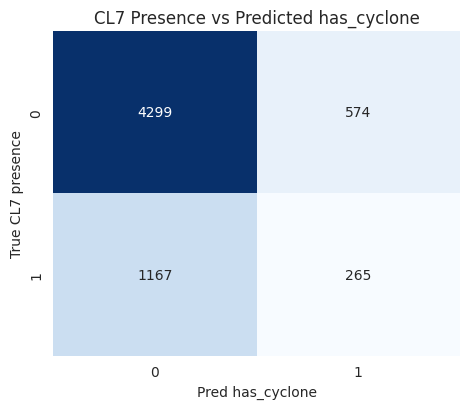

Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/cl7_confusion_matrix.png


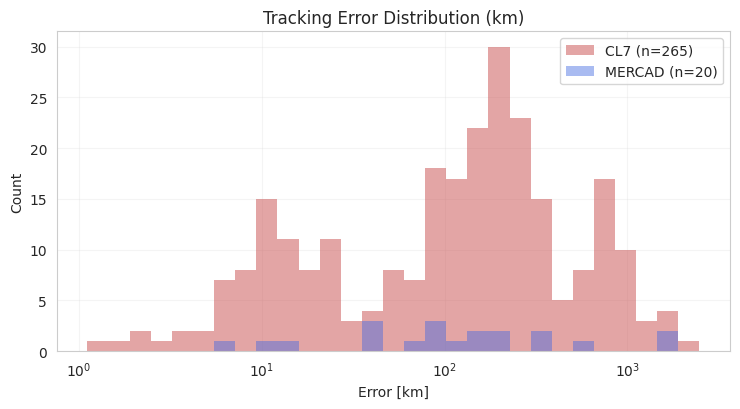

Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/cl7_mercad_error_hist_km.png


In [18]:
# CL7 validation (dry-run, no video)
# Riusa variabili/import globali del notebook: REPO_ROOT, np, pd, plt, sns, normalize_cyclone_id

VIDEOMAE_DIR = REPO_ROOT / 'moduli' / 'videomae'
if str(VIDEOMAE_DIR) not in sys.path:
    sys.path.insert(0, str(VIDEOMAE_DIR))

from track_from_folder import _parse_datetime_series
import engine_for_tracking as tracking_engine

NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
CL7_PRED_CSV = NOTEBOOKS_DIR / 'tracking_inference_predictions.csv'
CL7_LABELS_CSV = NOTEBOOKS_DIR / 'manos_CL7_pixel.csv'
MERCAD_LABELS_CSV = NOTEBOOKS_DIR / 'mercad_tracks_merged.csv'

CL7_OUT_DIR = NOTEBOOKS_DIR / 'cl7_validation_outputs'
CL7_OUT_DIR.mkdir(parents=True, exist_ok=True)
CL7_JOIN_CSV = CL7_OUT_DIR / 'tracking_inference_predictions_cl7_mercad_validation.csv'
CL7_CM_PNG = CL7_OUT_DIR / 'cl7_confusion_matrix.png'
CL7_HIST_PNG = CL7_OUT_DIR / 'cl7_mercad_error_hist_km.png'

for fp in [CL7_PRED_CSV, CL7_LABELS_CSV, MERCAD_LABELS_CSV]:
    if not fp.exists():
        raise FileNotFoundError(f'File non trovato: {fp}')

print('CL7_PRED_CSV:', CL7_PRED_CSV)
print('CL7_LABELS_CSV:', CL7_LABELS_CSV)
print('MERCAD_LABELS_CSV:', MERCAD_LABELS_CSV)

pred_df = pd.read_csv(CL7_PRED_CSV)
pred_df['datetime'] = _parse_datetime_series(pred_df.get('datetime'))
pred_df['has_cyclone'] = pd.to_numeric(pred_df.get('has_cyclone'), errors='coerce').fillna(0).astype(int)
pred_df['pred_lat'] = pd.to_numeric(pred_df.get('pred_lat'), errors='coerce')
pred_df['pred_lon'] = pd.to_numeric(pred_df.get('pred_lon'), errors='coerce')
pred_df = pred_df[pred_df['datetime'].notna()].copy().sort_values('datetime')

# GT CL7 disponibile ad ora intera: validazione hourly-only.
pred_df = pred_df[
    (pred_df['datetime'].dt.minute == 0)
    & (pred_df['datetime'].dt.second == 0)
    & (pred_df['datetime'].dt.microsecond == 0)
].copy()

cl7_df = pd.read_csv(CL7_LABELS_CSV)
cl7_df['time'] = _parse_datetime_series(cl7_df.get('time'))
cl7_df['lat'] = pd.to_numeric(cl7_df.get('lat'), errors='coerce')
cl7_df['lon'] = pd.to_numeric(cl7_df.get('lon'), errors='coerce')
cl7_df['cyclone_id'] = cl7_df.get('id_cyc_unico').apply(normalize_cyclone_id)
cl7_df = cl7_df[
    cl7_df['time'].notna() & cl7_df['lat'].notna() & cl7_df['lon'].notna() & (cl7_df['cyclone_id'] != '')
].copy().sort_values('time')

mercad_df = pd.read_csv(MERCAD_LABELS_CSV)
mercad_df['time'] = _parse_datetime_series(mercad_df.get('time'))
mercad_df['mercad_lat'] = pd.to_numeric(mercad_df.get('mercad_lat'), errors='coerce')
mercad_df['mercad_lon'] = pd.to_numeric(mercad_df.get('mercad_lon'), errors='coerce')
mercad_df = mercad_df[
    mercad_df['time'].notna() & mercad_df['mercad_lat'].notna() & mercad_df['mercad_lon'].notna()
].copy().sort_values('time')
mercad_df['time_hour'] = mercad_df['time'].dt.round('h')

if pred_df.empty:
    raise RuntimeError('Predizioni hourly vuote.')
if cl7_df.empty:
    raise RuntimeError('CL7 vuoto/non valido.')

overlap_start = max(pred_df['datetime'].min(), cl7_df['time'].min())
overlap_end = min(pred_df['datetime'].max(), cl7_df['time'].max())
if overlap_end < overlap_start:
    raise RuntimeError('Nessuna sovrapposizione temporale tra predictions e CL7.')

pred_eval = pred_df[(pred_df['datetime'] >= overlap_start) & (pred_df['datetime'] <= overlap_end)].copy().sort_values('datetime')
cl7_eval = cl7_df[(cl7_df['time'] >= overlap_start) & (cl7_df['time'] <= overlap_end)].copy()
mercad_eval = mercad_df[(mercad_df['time_hour'] >= overlap_start) & (mercad_df['time_hour'] <= overlap_end)].copy()

# Classification target: presenza CL7 al timestamp.
cl7_presence = cl7_eval.groupby('time').size().rename('cl7_n_points')
pred_eval = pred_eval.merge(cl7_presence, left_on='datetime', right_index=True, how='left')
pred_eval['cl7_n_points'] = pred_eval['cl7_n_points'].fillna(0).astype(int)
pred_eval['y_true_cl7_presence'] = (pred_eval['cl7_n_points'] > 0).astype(int)
pred_eval['y_pred_has_cyclone'] = pred_eval['has_cyclone'].astype(int)

cl7_by_time = {t: g for t, g in cl7_eval.groupby('time')}
mercad_by_time = {t: g for t, g in mercad_eval.groupby('time_hour')}

rows = []
for r in pred_eval.itertuples(index=False):
    dt = pd.Timestamp(r.datetime)
    pred_lat = pd.to_numeric(r.pred_lat, errors='coerce')
    pred_lon = pd.to_numeric(r.pred_lon, errors='coerce')
    has_cyc = int(r.has_cyclone)

    out = {
        'datetime': dt,
        'has_cyclone': has_cyc,
        'pred_lat': pred_lat,
        'pred_lon': pred_lon,
        'y_true_cl7_presence': int(r.y_true_cl7_presence),
        'y_pred_has_cyclone': int(r.y_pred_has_cyclone),
        'cl7_n_points': int(r.cl7_n_points),
        'cl7_match_id': '',
        'cl7_match_lat': np.nan,
        'cl7_match_lon': np.nan,
        'err_km_cl7': np.nan,
        'mercad_n_points': 0,
        'mercad_match_idorig': np.nan,
        'mercad_match_lat': np.nan,
        'mercad_match_lon': np.nan,
        'err_km_mercad': np.nan,
    }

    if has_cyc == 1 and np.isfinite(pred_lat) and np.isfinite(pred_lon):
        g = cl7_by_time.get(dt)
        if g is not None and not g.empty:
            d = tracking_engine._haversine_km(
                np.full(len(g), float(pred_lat)),
                np.full(len(g), float(pred_lon)),
                g['lat'].to_numpy(dtype=float),
                g['lon'].to_numpy(dtype=float),
            )
            i = int(np.argmin(d))
            row_i = g.iloc[i]
            out['cl7_match_id'] = normalize_cyclone_id(row_i.get('id_cyc_unico'))
            out['cl7_match_lat'] = float(row_i['lat'])
            out['cl7_match_lon'] = float(row_i['lon'])
            out['err_km_cl7'] = float(d[i])

        gm = mercad_by_time.get(dt)
        if gm is not None and not gm.empty:
            out['mercad_n_points'] = int(len(gm))
            d2 = tracking_engine._haversine_km(
                np.full(len(gm), float(pred_lat)),
                np.full(len(gm), float(pred_lon)),
                gm['mercad_lat'].to_numpy(dtype=float),
                gm['mercad_lon'].to_numpy(dtype=float),
            )
            j = int(np.argmin(d2))
            row_j = gm.iloc[j]
            out['mercad_match_idorig'] = row_j.get('idorig')
            out['mercad_match_lat'] = float(row_j['mercad_lat'])
            out['mercad_match_lon'] = float(row_j['mercad_lon'])
            out['err_km_mercad'] = float(d2[j])

    rows.append(out)

cl7_val_df = pd.DataFrame(rows).sort_values('datetime').reset_index(drop=True)
cl7_val_df.to_csv(CL7_JOIN_CSV, index=False)
print('Saved:', CL7_JOIN_CSV, '| rows:', len(cl7_val_df))

# --- confusion matrix ---
cm = pd.crosstab(
    cl7_val_df['y_true_cl7_presence'],
    cl7_val_df['y_pred_has_cyclone'],
    rownames=['True CL7 presence'],
    colnames=['Pred has_cyclone'],
    dropna=False,
).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

TN = int(cm.loc[0, 0]); FP = int(cm.loc[0, 1]); FN = int(cm.loc[1, 0]); TP = int(cm.loc[1, 1])
acc = (TP + TN) / max(1, (TP + TN + FP + FN))
prec = TP / max(1, (TP + FP))
rec = TP / max(1, (TP + FN))
f1 = 2 * prec * rec / max(1e-12, (prec + rec))

print(cm)
print(f'Accuracy={acc:.4f} Precision={prec:.4f} Recall={rec:.4f} F1={f1:.4f}')

fig, ax = plt.subplots(figsize=(4.8, 4.2), tight_layout=True)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues', ax=ax)
ax.set_title('CL7 Presence vs Predicted has_cyclone')
fig.savefig(CL7_CM_PNG, dpi=150)
plt.show()
print('Saved:', CL7_CM_PNG)

# --- error histogram ---
cl7_err = pd.to_numeric(cl7_val_df['err_km_cl7'], errors='coerce').dropna()
cl7_err = cl7_err[cl7_err > 0]
mercad_err = pd.to_numeric(cl7_val_df['err_km_mercad'], errors='coerce').dropna()
mercad_err = mercad_err[mercad_err > 0]

fig, ax = plt.subplots(figsize=(7.5, 4.2), tight_layout=True)
if not cl7_err.empty or not mercad_err.empty:
    vals = []
    if not cl7_err.empty:
        vals.extend(cl7_err.tolist())
    if not mercad_err.empty:
        vals.extend(mercad_err.tolist())
    bins = np.logspace(np.log10(max(1e-3, float(np.min(vals)))), np.log10(float(np.max(vals))), 30)

    if not cl7_err.empty:
        sns.histplot(cl7_err, bins=bins, color='indianred', alpha=0.55, ax=ax, label=f'CL7 (n={len(cl7_err)})')
    if not mercad_err.empty:
        sns.histplot(mercad_err, bins=bins, color='royalblue', alpha=0.45, ax=ax, label=f'MERCAD (n={len(mercad_err)})')

    ax.set_xscale('log')
    ax.set_xlabel('Error [km]')
    ax.set_ylabel('Count')
    ax.set_title('Tracking Error Distribution (km)')
    ax.grid(alpha=0.2)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No positive errors available', ha='center', va='center')
    ax.set_axis_off()

fig.savefig(CL7_HIST_PNG, dpi=150)
plt.show()
print('Saved:', CL7_HIST_PNG)


In [19]:
# CL7 static maps per-cyclone (periodo overlap con predictions)
# Crea una mappa PNG per ogni id_ciclone CL7 nel periodo, con:
# green=CL7 GT, red=predizioni matchate, blue=MERCAD matchato.
# La linea rossa e' tracciata solo nel window GT; fuori window restano solo i punti.

if '_plot_med_tracks_map' not in globals() or '_infer_gt_interval' not in globals() or '_build_track_title' not in globals():
    raise RuntimeError('Esegui prima la cella di configurazione mappe/helper.')
if 'cl7_val_df' not in globals():
    raise RuntimeError('Esegui prima la cella CL7 validation.')

maps_dir = CL7_OUT_DIR / 'maps_per_cyclone'
maps_dir.mkdir(parents=True, exist_ok=True)

cyclone_ids = sorted([cid for cid in cl7_eval['cyclone_id'].dropna().astype(str).unique() if cid])
print('Cyclones in overlap period:', len(cyclone_ids))

for cid in cyclone_ids:
    gt = cl7_eval[cl7_eval['cyclone_id'] == cid].copy().sort_values('time')
    gt_window = _infer_gt_interval(gt)

    pred_cid = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & (cl7_val_df['cl7_match_id'].astype(str) == str(cid))
        & cl7_val_df['pred_lat'].notna()
        & cl7_val_df['pred_lon'].notna()
    ].copy().sort_values('datetime')

    mercad_cid = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & (cl7_val_df['cl7_match_id'].astype(str) == str(cid))
        & cl7_val_df['mercad_match_lat'].notna()
        & cl7_val_df['mercad_match_lon'].notna()
    ].copy().sort_values('datetime')

    title = _build_track_title(cid, gt_df=gt)
    out_png = maps_dir / f'cyclone_{cid}.png'
    _plot_med_tracks_map(
        out_png=out_png,
        title=title,
        gt_df=gt.rename(columns={'lat': 'lat', 'lon': 'lon'}),
        pred_df=pred_cid.rename(columns={'datetime': 'time', 'pred_lat': 'lat', 'pred_lon': 'lon'}),
        mercad_df=(
            mercad_cid[['datetime', 'mercad_match_lat', 'mercad_match_lon']].rename(
                columns={'datetime': 'time', 'mercad_match_lat': 'lat', 'mercad_match_lon': 'lon'}
            )
            if not mercad_cid.empty
            else mercad_cid
        ),
        gt_label='CL7 GT',
        pred_label='Prediction',
        mercad_label='MERCAD',
        pred_connect_window=gt_window,
        dpi=140,
    )

print('Saved static maps in:', maps_dir)



Cyclones in overlap period: 29
Saved static maps in: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/maps_per_cyclone


In [ ]:
# CL7 video (opzionale, pesante)
# Tracce aggregate nel tempo: green=CL7, red=predictions, blue=MERCAD

CREATE_CL7_VIDEO = False  # dry-run default
VIDEO_FPS = 10

if not CREATE_CL7_VIDEO:
    print('CREATE_CL7_VIDEO=False -> skip rendering video (dry-run).')
else:
    if 'create_basemap_obj' not in globals():
        from medicane_utils.geo_const import latcorners, loncorners, create_basemap_obj

    frames_dir = CL7_OUT_DIR / 'video_frames'
    video_path = CL7_OUT_DIR / 'cl7_validation_traces.mp4'

    if frames_dir.exists():
        shutil.rmtree(frames_dir)
    frames_dir.mkdir(parents=True, exist_ok=True)

    pred_all = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & cl7_val_df['pred_lat'].notna()
        & cl7_val_df['pred_lon'].notna()
    ].copy().sort_values('datetime')

    frame_times = sorted(cl7_val_df['datetime'].dropna().unique())
    for i, dt in enumerate(frame_times):
        fig = plt.figure(figsize=(9, 6), dpi=120)
        ax = fig.add_axes([0.07, 0.08, 0.86, 0.84])
        m = create_basemap_obj(ax=ax)
        m.drawcoastlines(linewidth=0.8, color='black', zorder=2)

        lat_min, lat_max = latcorners
        lon_min, lon_max = loncorners
        parallels = np.arange(lat_min, lat_max + 0.1, 2.0)
        meridians = np.arange(lon_min, lon_max + 0.1, 2.0)
        m.drawparallels(parallels, labels=[1, 0, 0, 0], fontsize=8, color='0.5')
        m.drawmeridians(meridians, labels=[0, 0, 0, 1], fontsize=8, color='0.5', rotation=45)

        cl7_upto = cl7_eval[cl7_eval['time'] <= dt]
        pred_upto = pred_all[pred_all['datetime'] <= dt]
        mercad_upto = cl7_val_df[
            (cl7_val_df['datetime'] <= dt)
            & cl7_val_df['mercad_match_lat'].notna()
            & cl7_val_df['mercad_match_lon'].notna()
        ]

        if not cl7_upto.empty:
            xg, yg = m(cl7_upto['lon'].to_numpy(), cl7_upto['lat'].to_numpy())
            m.plot(xg, yg, color='green', linewidth=1.2, alpha=0.75)
            cl7_now = cl7_eval[cl7_eval['time'] == dt]
            if not cl7_now.empty:
                xg0, yg0 = m(cl7_now['lon'].to_numpy(), cl7_now['lat'].to_numpy())
                m.scatter(xg0, yg0, c='green', s=14, marker='o', zorder=5, label='CL7 GT')

        if not pred_upto.empty:
            xr, yr = m(pred_upto['pred_lon'].to_numpy(), pred_upto['pred_lat'].to_numpy())
            m.plot(xr, yr, color='red', linewidth=1.2, alpha=0.8)
            pred_now = pred_all[pred_all['datetime'] == dt]
            if not pred_now.empty:
                xr0, yr0 = m(pred_now['pred_lon'].to_numpy(), pred_now['pred_lat'].to_numpy())
                m.scatter(xr0, yr0, c='red', s=14, marker='o', zorder=6, label='Prediction')

        if not mercad_upto.empty:
            xb, yb = m(mercad_upto['mercad_match_lon'].to_numpy(), mercad_upto['mercad_match_lat'].to_numpy())
            m.plot(xb, yb, color='royalblue', linewidth=1.2, alpha=0.75)
            mercad_now = mercad_upto[mercad_upto['datetime'] == dt]
            if not mercad_now.empty:
                xb0, yb0 = m(mercad_now['mercad_match_lon'].to_numpy(), mercad_now['mercad_match_lat'].to_numpy())
                m.scatter(xb0, yb0, c='royalblue', s=14, marker='o', zorder=7, label='MERCAD')

        ax.set_title(f'CL7 validation tracks | {pd.Timestamp(dt).strftime("%Y-%m-%d %H:%M")}')
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            uniq = {}
            for h, l in zip(handles, labels):
                if l not in uniq:
                    uniq[l] = h
            ax.legend(uniq.values(), uniq.keys(), loc='lower left', fontsize=8)

        fig.savefig(frames_dir / f'frame_{i:05d}.png', dpi=120)
        plt.close(fig)

    ffmpeg = shutil.which('ffmpeg')
    if ffmpeg is None:
        print('[WARN] ffmpeg non trovato: video non creato.')
    else:
        cmd = [
            ffmpeg,
            '-y',
            '-framerate', str(int(VIDEO_FPS)),
            '-i', str(frames_dir / 'frame_%05d.png'),
            '-c:v', 'libx264',
            '-crf', '18',
            '-preset', 'medium',
            '-pix_fmt', 'yuv420p',
            str(video_path),
        ]
        subprocess.run(cmd, check=True)
        print('Saved video:', video_path)
